In [1]:
import sys, os
# ensure parent directory is on the path so `src` package can be imported
sys.path.insert(0, os.path.abspath('../..'))

In [2]:
# configura per importare da src
import sys
sys.path.append('./src')

## LOAD DATASET

In [3]:
from src.CHM.model import ConceptBottleneckClassifier
from src.CHM.train import train_cbm_classifier
import matplotlib.pyplot as plt
import torch.nn as nn
from src.CHM.test import test_zsl_cbm_classifier
from src.utils.plot import plot_zsl_test_results, plot_concept_error_heatmap, analyze_misclassifications_concepts, plot_concept_uncertainty_heatmap

AllenNLP not available. Registrable won't work.


In [4]:
from src.utils.dataset import load_concept_data, prepare_class_concept_dataset, parse_classes, parse_concepts
import torch
import numpy as np

concepts = parse_concepts('../../AwA2_Dataset_Labels/Animals_with_Attributes2/extended_concepts.txt')
classes = parse_classes('../../AwA2_Dataset_Labels/Animals_with_Attributes2/classes.txt')
class2id = {c: idx for idx, c in enumerate(classes)}
class_concept_matrix = torch.from_numpy(np.loadtxt('../../Awa2_Dataset_Labels/Animals_with_Attributes2/extended_matrix.txt', dtype=int))
dataset, concept2id, id2concept = load_concept_data('../../AwA2_Dataset_Labels/Animals_with_Attributes2/supervisioni_gerarchia.json', concepts)
datasetClasses = prepare_class_concept_dataset(class_concept_matrix, class2id)

In [5]:
from src.utils.dataset import zsl_split_awa2_features
from torch.utils.data import DataLoader, TensorDataset

features_path = '../../AwA2_Dataset_Features/Animals_with_Attributes2/Features/ResNet101/AwA2-features.txt'
labels_path = '../../AwA2_Dataset_Features/Animals_with_Attributes2/Features/ResNet101/AwA2-labels.txt'
test_path = '../../AwA2_Dataset_Labels/Animals_with_Attributes2/zsl/testclasses.txt'
trainval_path = '../../AwA2_Dataset_Labels/Animals_with_Attributes2/zsl/trainvalclasses.txt'
classes_path = '../../AwA2_Dataset_Labels/Animals_with_Attributes2/classes.txt'

(X_train, y_train), (X_test, y_test) = zsl_split_awa2_features(
    features_path, labels_path, classes_path, trainval_path, test_path, val_split_path=None
)

BATCH_SIZE = 32
EPOCHS = 6
NUM_CLASSES = len(set(y_train))
NUM_CONCEPTS = len(concept2id)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

train_dataset = TensorDataset(torch.tensor(X_train).float(), torch.tensor(y_train).long())
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
test_dataset = TensorDataset(torch.tensor(X_test).float(), torch.tensor(y_test).long())
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, pin_memory=True)

Caricamento in corso... (potrebbe richiedere qualche secondo)
Dimensioni totali feature: (37322, 2048)
Training set: 29409 samples (40 classi)
Test set: 7913 samples (10 classi)
Using device: cpu


In [6]:
test_ids = set(y_test)
print(test_ids)
unseen_idx_list = [i - 1 for i in test_ids]
print(f"Unseen class indices for testing: {unseen_idx_list}")

{np.int64(34), np.int64(7), np.int64(9), np.int64(41), np.int64(47), np.int64(50), np.int64(23), np.int64(24), np.int64(30), np.int64(31)}
Unseen class indices for testing: [np.int64(33), np.int64(6), np.int64(8), np.int64(40), np.int64(46), np.int64(49), np.int64(22), np.int64(23), np.int64(29), np.int64(30)]


## BOX

In [7]:
from src.BOX.model import BoxHierarchyModelJoint
from src.utils.box import get_geometric_class_weights

BOX_DIM = 16

info = 'dynamic_box'
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

box_model = BoxHierarchyModelJoint(num_concepts=len(concepts), num_classes=len(classes), dim=BOX_DIM)
box_model.load_state_dict(torch.load("../../AwA2_Dataset_Labels/Animals_with_Attributes2/modello_gerarchia_joint.pth"))
W_geom = get_geometric_class_weights(box_model, len(classes), len(concepts), device)

## CONCEPT PREDICTOR

In [8]:
from src.CP.model import ConceptPredictor

concept_predictor = ConceptPredictor(X_train.shape[1], num_concepts=NUM_CONCEPTS)
optimizer = torch.optim.Adam(concept_predictor.parameters(), lr=0.001)
criterion = nn.BCEWithLogitsLoss()

In [9]:
from src.CHM.train import train_concept_predictor

history = train_concept_predictor(
    concept_predictor, 
    train_dataloader, 
    None, 
    class_concept_matrix, 
    optimizer, 
    criterion, 
    EPOCHS, 
    device
)

Loss: 2.7096 | Acc: 97.0062 
Loss: 1.6451 | Acc: 98.1501 
Loss: 1.4229 | Acc: 98.3863 
Loss: 1.2950 | Acc: 98.5286 
Loss: 1.2021 | Acc: 98.6298 
Loss: 1.1343 | Acc: 98.6986 


## COSINE SIMILARITY

In [10]:
from src.CHM.test import test_zsl_cosine_similarity

cp_accuracy, cp_all_preds, cp_all_labels_mapped = test_zsl_cosine_similarity(
    concept_predictor,
    test_dataloader,
    class_concept_matrix,
    unseen_idx_list,
    device
)

Accuratezza ZSL (Cosine Similarity Baseline): 39.66%


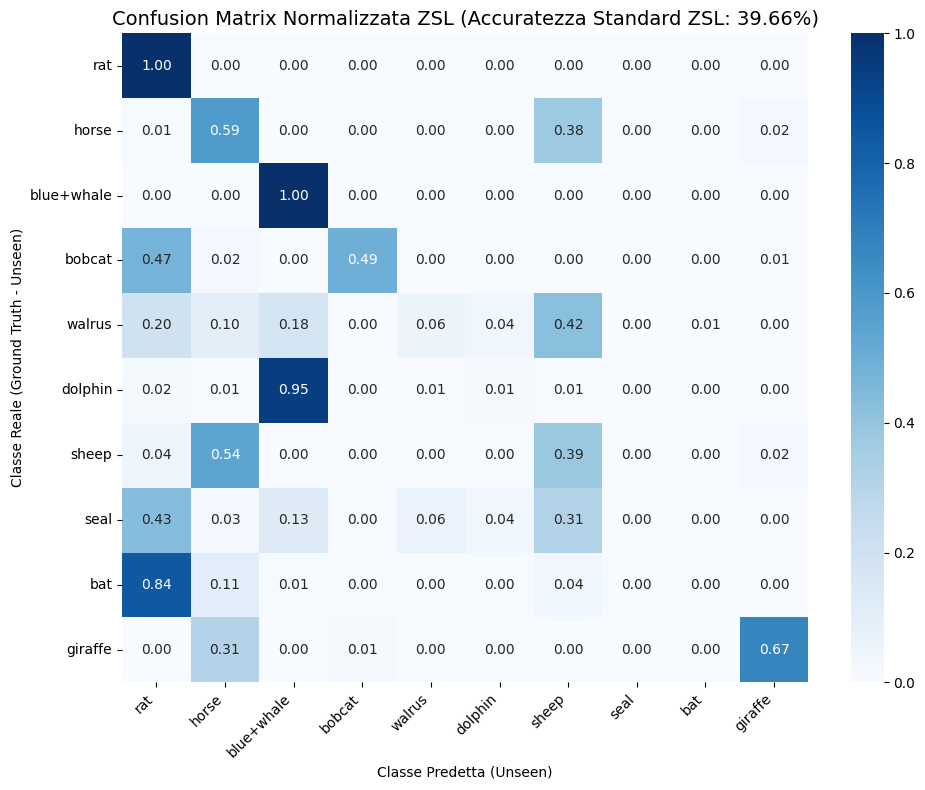


Analisi degli Errori Principali nel Test Set Zero-Shot:
 - 897 volte: 'dolphin' è stato scambiato per 'blue+whale'
 - 773 volte: 'sheep' è stato scambiato per 'horse'
 - 623 volte: 'horse' è stato scambiato per 'sheep'
 - 426 volte: 'seal' è stato scambiato per 'rat'
 - 373 volte: 'giraffe' è stato scambiato per 'horse'


In [11]:
unseen_mapping_for_plot = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
id2class = {idx: c for c, idx in class2id.items()}
unseen_class_names_for_plot = [id2class[idx] for idx in unseen_idx_list]
plot_zsl_test_results(cp_accuracy, cp_all_preds, cp_all_labels_mapped, unseen_mapping_for_plot, class_names=unseen_class_names_for_plot)

## GEOMETRIC CLASSIFIER

In [12]:
concept_weights = box_model.concept_embeddings.weight
class_weights = box_model.class_embeddings.weight
info = 'dynamic_box'
db_model = ConceptBottleneckClassifier(
        num_concepts=len(concepts), 
        box_dim=BOX_DIM, 
        num_classes=len(classes), 
        info=info, 
        concept_embeddings=concept_weights,
        class_embeddings=class_weights
)
info = 'geometric'
g_model = ConceptBottleneckClassifier(
        num_concepts=len(concepts), 
        num_classes=len(classes), 
        box_dim=BOX_DIM, 
        info=info, 
        geometric_weights=W_geom
)

### Joint training

In [ ]:
from src.CP.model import ConceptPredictor

db_concept_predictor = ConceptPredictor(X_train.shape[1], num_concepts=NUM_CONCEPTS)
db_optimizer = torch.optim.Adam(concept_predictor.parameters(), lr=0.001)
criterion = nn.BCEWithLogitsLoss()

In [ ]:
from src.CHM.train import joint_training_frozen_geometric

db_cls_criterion = nn.CrossEntropyLoss()
lambda_c = 1.0
gamma_hierarchy = 1.5
logit_temp = 0.5

db_history = joint_training_frozen_geometric(
    db_model,
    db_concept_predictor,
    train_dataloader,
    #val_dataloader,
    class_concept_matrix,
    #prob_matrix,
    optimizer=db_optimizer,
    criterion_cls=db_cls_criterion,
    concept_weights=concept_weights,
    epochs=EPOCHS,
    device=device,
    lambda_c=lambda_c,
    gamma_h=gamma_hierarchy,
    logit_temperature=logit_temp,
)   

In [22]:
box_tensors = None
db_accuracy, db_preds, db_labels, db_concepts_preds, db_concepts_truth, db_concepts_probs = test_zsl_cbm_classifier(
     model=db_model,
     test_dataloader=test_dataloader,
     class_concept_matrix=class_concept_matrix,
     boxes_tensor=box_tensors,
     device="cuda" if torch.cuda.is_available() else "cpu",
     info=info,
     bipolar=False,
     oracle=False,
     concept_predictor=concept_predictor,
     unseen_classes_idx=unseen_idx_list,
     #smoothing_logic=True,
     #alpha=0.7
)

Inizio valutazione Zero-Shot (SZSL) sul Test Set...

Accuratezza ZSL Totale: 35.46%


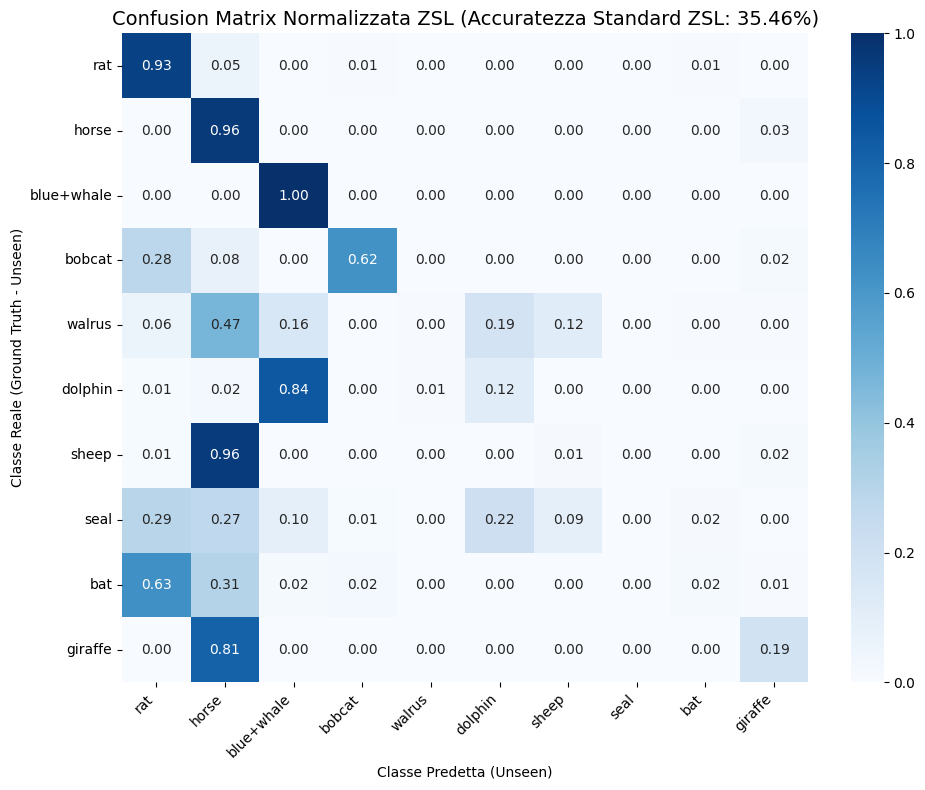


Analisi degli Errori Principali nel Test Set Zero-Shot:
 - 1358 volte: 'sheep' è stato scambiato per 'horse'
 - 971 volte: 'giraffe' è stato scambiato per 'horse'
 - 799 volte: 'dolphin' è stato scambiato per 'blue+whale'
 - 290 volte: 'seal' è stato scambiato per 'rat'
 - 268 volte: 'seal' è stato scambiato per 'horse'


In [14]:
plot_zsl_test_results(db_accuracy, db_preds, db_labels, unseen_idx_list, class_names=classes)

In [15]:
box_tensors = None
g_accuracy, g_preds, g_labels, g_concepts_preds, g_concepts_truth, g_concepts_probs = test_zsl_cbm_classifier(
     model=g_model,
     test_dataloader=test_dataloader,
     class_concept_matrix=class_concept_matrix,
     boxes_tensor=box_tensors,
     device="cuda" if torch.cuda.is_available() else "cpu",
     info=info,
     bipolar=False,
     oracle=False,
     concept_predictor=concept_predictor,
     unseen_classes_idx=unseen_idx_list
)

Inizio valutazione Zero-Shot (SZSL) sul Test Set...

Accuratezza ZSL Totale: 34.45%


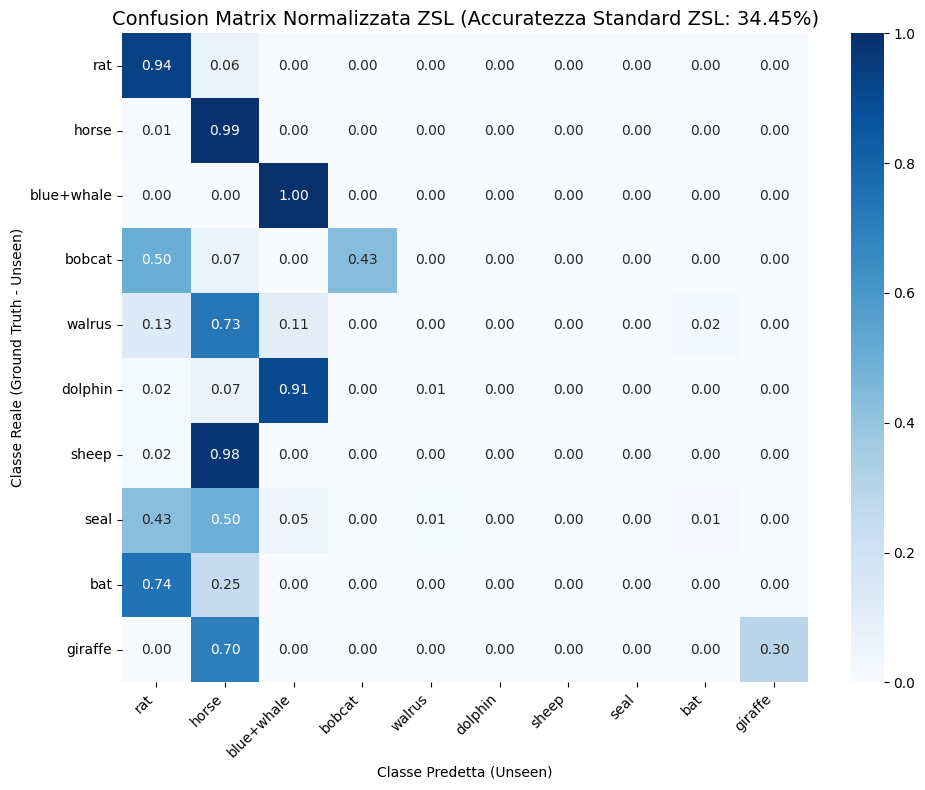


Analisi degli Errori Principali nel Test Set Zero-Shot:
 - 1388 volte: 'sheep' è stato scambiato per 'horse'
 - 860 volte: 'dolphin' è stato scambiato per 'blue+whale'
 - 843 volte: 'giraffe' è stato scambiato per 'horse'
 - 490 volte: 'seal' è stato scambiato per 'horse'
 - 423 volte: 'seal' è stato scambiato per 'rat'


In [16]:
plot_zsl_test_results(g_accuracy, g_preds, g_labels, unseen_idx_list, class_names=classes)